# Normal Distribution


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from arviz import convert_to_inference_data, summary
from IPython.display import display
from scipy.stats import gaussian_kde
from tqdm import trange

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

In [3]:
def mcmc_plots(runs, burnin=0, param_string=None, isvariance=True):
    """
    Posterior plots

    Inputs
    runs          --- Monte Carlo sample
    burnin        --- the number of runs in the burnin stage
    isvariance   ---- True if the variance is included

    Outputs
    kde_x         --- grid
    kde_posterior --- kernel density estimation
    """
    grid = 250
    k = runs.shape[1]
    kde_x = np.zeros((grid, k))
    kde_posterior = np.zeros((grid, k))
    if isvariance:
        num_b = k - 1
    else:
        num_b = k
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    fig, ax = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k), facecolor='w')
    for index in range(k):
        mc_trace = runs[burnin:, index]
        if index < num_b:
            x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        else:
            x_min = 0.0
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        posterior = gaussian_kde(mc_trace).evaluate(x)
        ax[index, 0].plot(mc_trace, linewidth=0.1)
        ax[index, 0].set_xlim(1, draws)
        ax[index, 0].set_ylabel(y_label)
        ax[index, 1].plot(x, posterior)
        ax[index, 1].set_xlim(x_min, x_max)
        ax[index, 1].set_ylim(0, 1.1*posterior.max())
        ax[index, 1].set_ylabel('Density')
        kde_x[:, index] = x
        kde_posterior[:, index] = posterior
    ax[-1, 0].set_xlabel('Random Sequence')
    ax[-1, 1].set_xlabel('Posterior Distribution')
    plt.tight_layout()
    plt.show
    return kde_x, kde_posterior

## Gibbs sampler for $\mathrm{Normal}(\mu,\sigma^{2})$

$$
\begin{split}
\mu^{(r)} &\leftarrow \mathrm{Normal}\left(\frac{n(\sigma^{2(r-1)})^{-1}\bar{x} + \tau_{0}^{-2}\mu_{0}}{n(\sigma^{2(r-1)})^{-1} + \tau_{0}^{-2}}, \frac1{n(\sigma^{2(r-1)})^{-1} + \tau_{0}^{-2}}\right). \\
\sigma^{2(r)} &\leftarrow \mathrm{Inv.Gamma}\left(\frac{n+\nu_{0}}{2}, \frac{n(\mu^{(r)}-\bar{x})^{2}+\sum_{i=1}^n(x_{i}-\bar{x})^{2}+\lambda_{0}}{2}\right), \\
\bar{x} &= \frac1{n}\sum_{i=1}^{n}x_{i}.
\end{split}
$$


In [4]:
def gibbs_normal(data, hyper_param, burnin=1000, draws=10000, rng=None):
    """
    Gibbs sampler for normal distribution

    Inputs
    data --- data (n x 1)
    hyper_param = [mu0, tau0, nu0, lam0]
    mu0  --- the prior mean of the population mean
    tau0 --- the prior variance of the population mean
    nu0  --- the prior shape parameter of the populatin variance
    lam0 --- the prir scale parameter of the population variance
    burnin  --- the number of runs in the burnin stage
    draws   --- the number of runs in the sampling stage
    rng     --- the initial state of the random number generator

    Outputs
    runs    --- Monte Carlo sample ((burnin + draws) x 2)
                column 0    population mean
                column 1    population variance
    """
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    mu0, tau0, nu0, lam0 = hyper_param
    n = data.size
    sum_data = data.sum()
    mean_data = sum_data / n
    variance_data = data.var()
    inv_tau02 = 1.0 / tau0**2
    mu0_tau02 = mu0 * inv_tau02
    a = 0.5 * (n + nu0)
    c = n * variance_data + lam0
    sigma2 = variance_data
    runs = np.empty((iterations, 2))
    for it in trange(iterations):
        variance_mu = 1.0 / (n / sigma2 + inv_tau02)
        mean_mu = variance_mu * (sum_data / sigma2 + mu0_tau02)
        mu = rng.normal(loc=mean_mu, scale=np.sqrt(variance_mu))
        b = 0.5 * (n * (mu - mean_data)**2 + c)
        sigma2 = b / rng.gamma(a)
        runs[it, 0] = mu
        runs[it, 1] = sigma2
    return runs

In [5]:
mu = 1.0
sigma = 2.0
n = 50
rng = np.random.default_rng(seed=99)
data = rng.normal(loc=mu, scale=sigma, size=n)

In [6]:
mu0 = 0.0
tau0 = 10.0
nu0 = 5.0
lam0 = 7.0
hyper_param = [mu0, tau0, nu0, lam0]
burnin = 2000
draws = 20000
runs = gibbs_normal(data, hyper_param, burnin=burnin, draws=draws, rng=rng)

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 22000/22000 [00:00<00:00, 574708.91it/s]


In [7]:
results = mcmc_stats(runs, burnin=burnin, param_string=['$\\mu$','$\\sigma^{2}$'])
display(results)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\mu$,1.481,0.242,0.994,1.942,0.002,0.001,19851.0,19348.0,1.0
$\sigma^{2}$,2.976,0.592,1.943,4.180,0.004,0.004,19145.0,19536.0,1.0


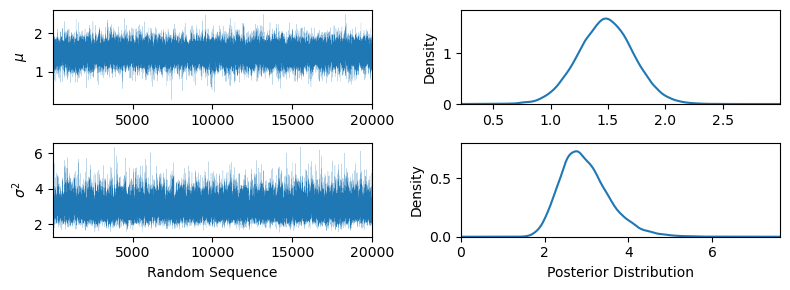

In [8]:
_ = mcmc_plots(runs, burnin=burnin, param_string=['$\\mu$','$\\sigma^{2}$'])